# Phase 5: Threshold Calibration + SHAP Explainability

### What this notebook does:
1. Load the trained model bundle from Phase 4
2. **Threshold Calibration** — find the optimal per-endpoint decision threshold on the **calibration split** (not test set)
3. **SHAP GradientExplainer** — compute per-bit importance scores for each of the 12 endpoints
4. Save the updated model artifact bundle (with thresholds baked in)
5. Visualise the top-20 most important fingerprint bits per endpoint

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import torch
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.train import get_device
from src.explain import (
    load_pipeline_from_artifact,
    calibrate_thresholds,
    compute_shap_values,
    build_global_shap_summary,
)

TARGET_COLS = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
    'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]

device = get_device()
print('Phase 5 ready.')

GPU active: NVIDIA GeForce RTX 5050 Laptop GPU
Phase 5 ready.


In [3]:
# ── Load Model + Data ──────────────────────────────────────────────────────────
print('Loading model artifact...')
ARTIFACT_PATH = '../models/model_artifact.pkl'
pipeline, artifact = load_pipeline_from_artifact(ARTIFACT_PATH, device)
print(f'Model loaded. Best AUPRC from Phase 4: {artifact["optuna_best_value"]:.4f}')

# Load calibration and training splits
print('Loading feature matrices...')
X_fp_calib = np.load('../data/processed/splits/X_fp_calib.npy')
X_fp_train = np.load('../data/processed/splits/X_fp_train.npy')
calib_idx  = np.load('../data/processed/splits/calib_idx.npy')

df = pd.read_csv('../data/processed/tox21_cleaned.csv')
Y_all   = df[TARGET_COLS].values
Y_calib = Y_all[calib_idx]

print(f'Calibration set: {X_fp_calib.shape[0]} molecules')
print(f'Training set:    {X_fp_train.shape[0]} molecules (used as SHAP background)')

Loading model artifact...
Model loaded. Best AUPRC from Phase 4: 0.4308
Loading feature matrices...
Calibration set: 780 molecules
Training set:    5460 molecules (used as SHAP background)


In [4]:
# ── Step 1: Threshold Calibration ─────────────────────────────────────────────
# Finds the optimal classification threshold for each of the 12 endpoints
# by maximising F1 score on the CALIBRATION set (not the test set).

optimal_thresholds = calibrate_thresholds(
    pipeline=pipeline,
    X_calib=X_fp_calib,
    Y_calib=Y_calib,
    target_cols=TARGET_COLS,
    device=device,
)

print('\nOptimal thresholds per endpoint:')
for ep, thr in optimal_thresholds.items():
    print(f'  {ep}: {thr}')


Threshold Calibration (Calibration Split)
--------------------------------------------------
  NR-AR               : threshold=0.680  (F1=0.755, toxic=8.5%)
  NR-AR-LBD           : threshold=0.610  (F1=0.698, toxic=7.0%)
  NR-AhR              : threshold=0.420  (F1=0.516, toxic=14.7%)
  NR-Aromatase        : threshold=0.090  (F1=0.276, toxic=8.3%)
  NR-ER               : threshold=0.410  (F1=0.441, toxic=15.5%)
  NR-ER-LBD           : threshold=0.570  (F1=0.349, toxic=5.2%)
  NR-PPAR-gamma       : threshold=0.370  (F1=0.222, toxic=4.8%)
  SR-ARE              : threshold=0.090  (F1=0.385, toxic=19.6%)
  SR-ATAD5            : threshold=0.210  (F1=0.310, toxic=5.0%)
  SR-HSE              : threshold=0.610  (F1=0.364, toxic=6.7%)
  SR-MMP              : threshold=0.310  (F1=0.573, toxic=20.9%)
  SR-p53              : threshold=0.060  (F1=0.248, toxic=9.0%)

Optimal thresholds per endpoint:
  NR-AR: 0.68
  NR-AR-LBD: 0.61
  NR-AhR: 0.42
  NR-Aromatase: 0.09
  NR-ER: 0.41
  NR-ER-LBD: 0.57


In [5]:
# ── Step 2: SHAP GradientExplainer ────────────────────────────────────────────
# Computes per-bit SHAP values for 100 molecules from the calibration set.
# Background: 150 random molecules from the training set.
# Runtime: approx 2-5 minutes.

shap_values, explained_idx = compute_shap_values(
    pipeline=pipeline,
    X_train_bg=X_fp_train,
    X_explain=X_fp_calib,
    device=device,
    n_background=150,
    n_explain=100,
)

# Build global summary: top-15 bits per endpoint
shap_summary = build_global_shap_summary(shap_values, TARGET_COLS, top_k=15)

print('\nTop-5 most important bits per endpoint:')
for ep, bits in shap_summary.items():
    top5 = [f"bit_{b['bit']}({b['importance']:.4f})" for b in bits[:5]]
    print(f'  {ep}: {top5}')

  Background: 150 molecules | Explaining: 100 molecules
  Running SHAP GradientExplainer (this takes 2–5 minutes)...
  SHAP complete. Output shape: (100, 4096, 12)

Top-5 most important bits per endpoint:
  NR-AR: ['bit_875(0.0042)', 'bit_2974(0.0035)', 'bit_2983(0.0033)', 'bit_3105(0.0032)', 'bit_519(0.0027)']
  NR-AR-LBD: ['bit_3105(0.0035)', 'bit_519(0.0028)', 'bit_3639(0.0026)', 'bit_787(0.0026)', 'bit_547(0.0024)']
  NR-AhR: ['bit_875(0.0142)', 'bit_3105(0.0101)', 'bit_2983(0.0070)', 'bit_695(0.0058)', 'bit_3247(0.0057)']
  NR-Aromatase: ['bit_3105(0.0064)', 'bit_2983(0.0047)', 'bit_875(0.0044)', 'bit_378(0.0035)', 'bit_2698(0.0033)']
  NR-ER: ['bit_3105(0.0103)', 'bit_3247(0.0095)', 'bit_389(0.0083)', 'bit_875(0.0072)', 'bit_2974(0.0065)']
  NR-ER-LBD: ['bit_875(0.0039)', 'bit_807(0.0034)', 'bit_3105(0.0033)', 'bit_622(0.0028)', 'bit_519(0.0024)']
  NR-PPAR-gamma: ['bit_3105(0.0089)', 'bit_807(0.0075)', 'bit_2362(0.0065)', 'bit_3247(0.0057)', 'bit_3959(0.0049)']
  SR-ARE: ['bit_3

In [6]:
# ── Step 3: Save Updated Model Artifact ───────────────────────────────────────
# Inject calibrated thresholds and SHAP summary into the artifact bundle.

artifact['thresholds']    = optimal_thresholds
artifact['shap_summary']  = shap_summary
artifact['shap_values']   = shap_values    # Full matrix for downstream use
artifact['shap_exp_idx']  = explained_idx

with open(ARTIFACT_PATH, 'wb') as f:
    pickle.dump(artifact, f)

print('Updated model artifact saved with:')
print(f'  Thresholds:   {list(optimal_thresholds.values())}')
print(f'  SHAP values:  shape={shap_values.shape}')
print('Phase 5 Complete.')

Updated model artifact saved with:
  Thresholds:   [0.68, 0.61, 0.42, 0.09, 0.41, 0.57, 0.37, 0.09, 0.21, 0.61, 0.31, 0.06]
  SHAP values:  shape=(100, 4096, 12)
Phase 5 Complete.


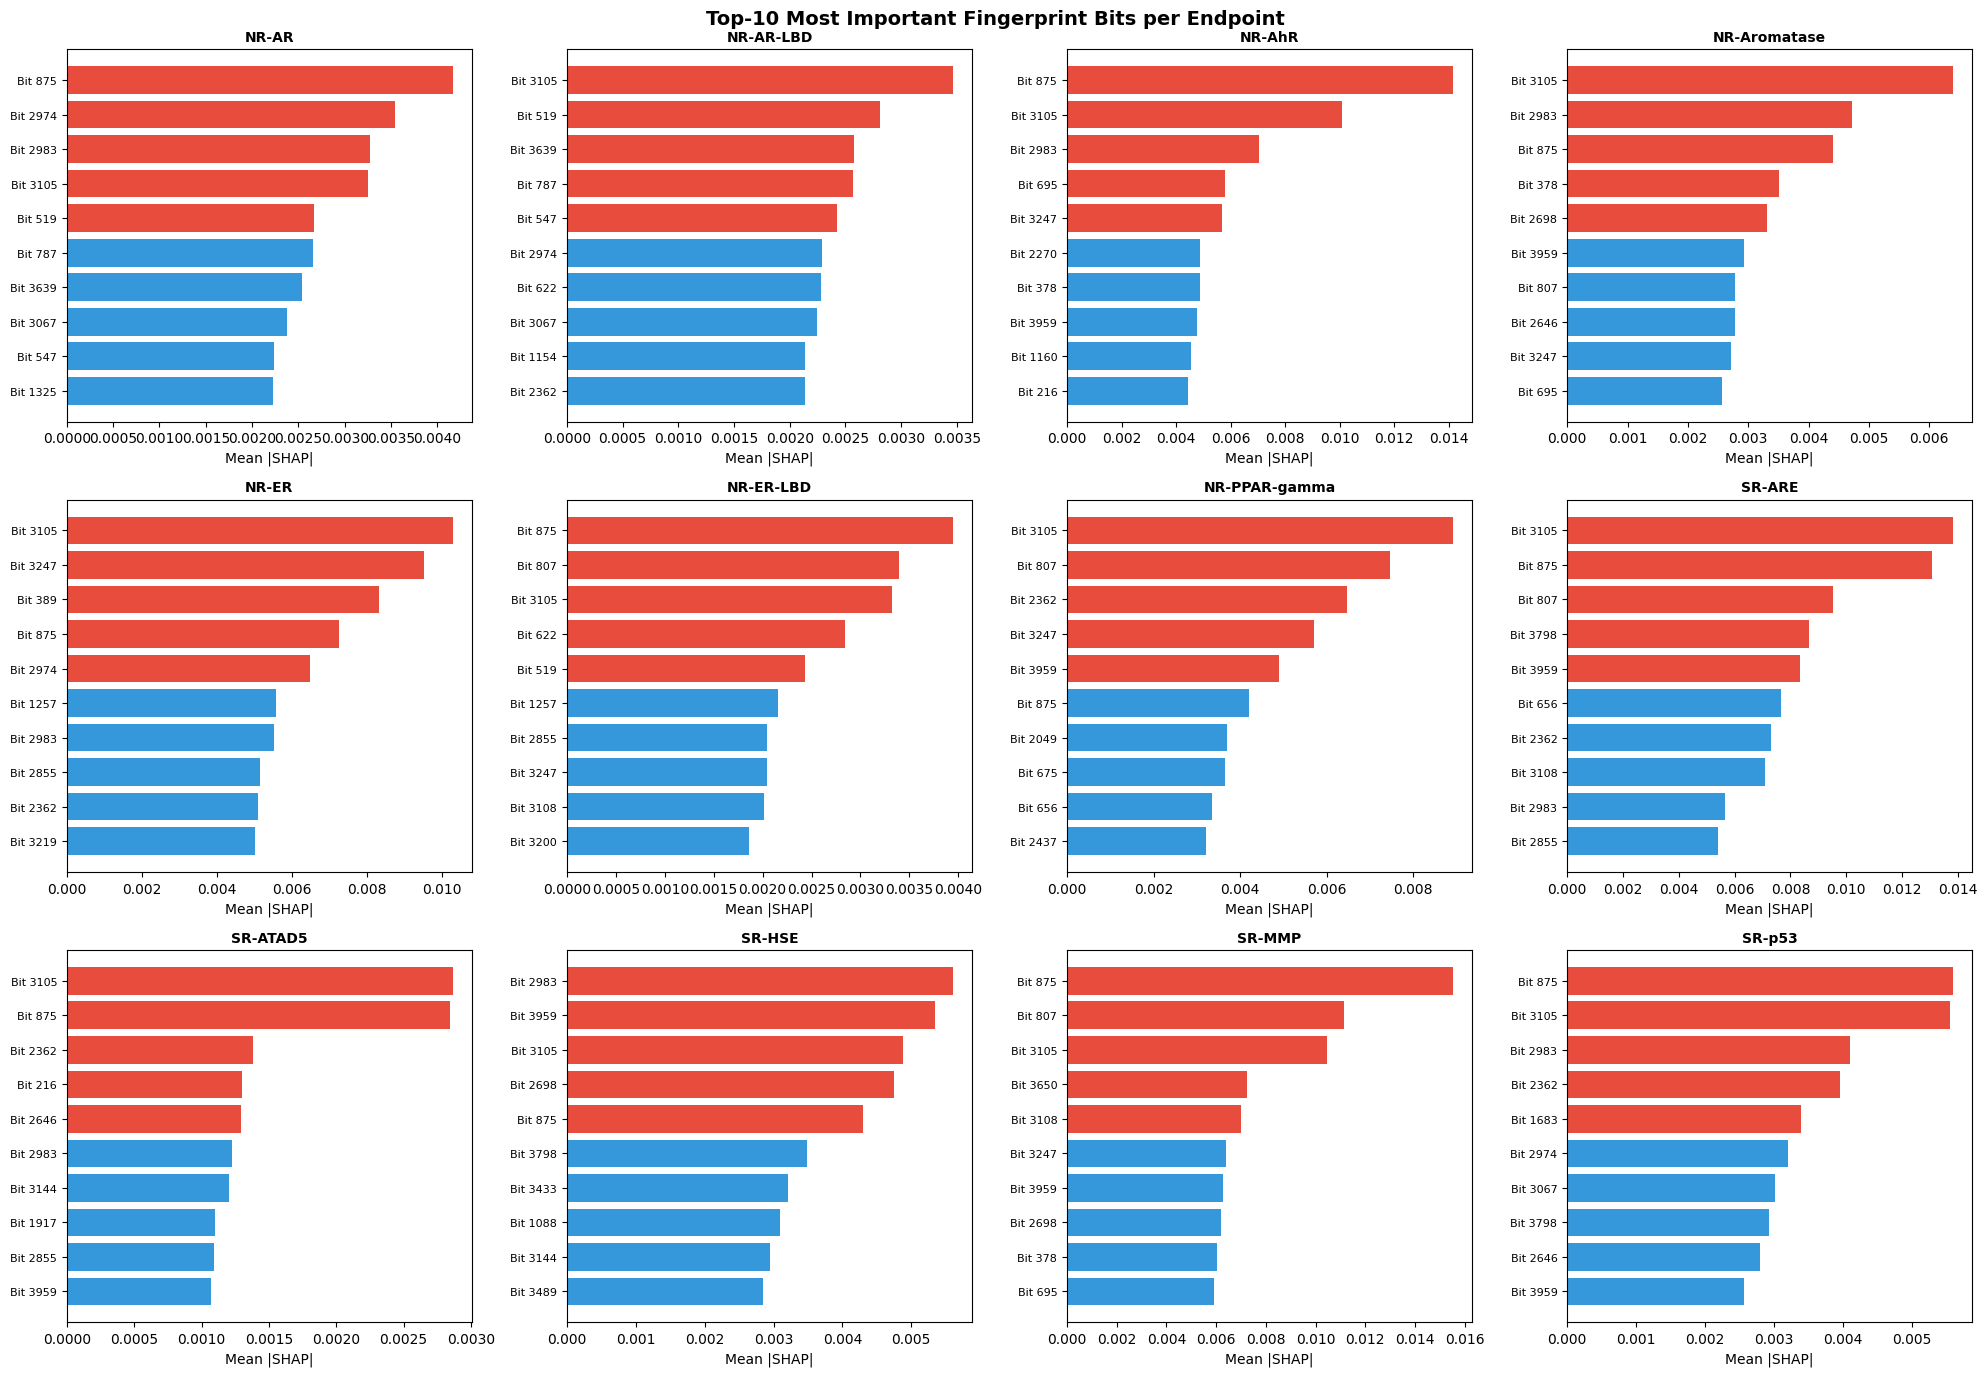

SHAP importance plot saved.


In [7]:
# ── Step 4: Visualise SHAP Bit Importance ─────────────────────────────────────
# Plot global SHAP importance (mean absolute value) for each endpoint.

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, (col, bits) in enumerate(shap_summary.items()):
    ax = axes[i]
    bit_labels  = [f"Bit {b['bit']}" for b in bits[:10]]
    importances = [b['importance'] for b in bits[:10]]

    colors = ['#e74c3c' if v > np.median(importances) else '#3498db' for v in importances]
    ax.barh(bit_labels[::-1], importances[::-1], color=colors[::-1])
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel('Mean |SHAP|')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top-10 Most Important Fingerprint Bits per Endpoint', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP importance plot saved.')

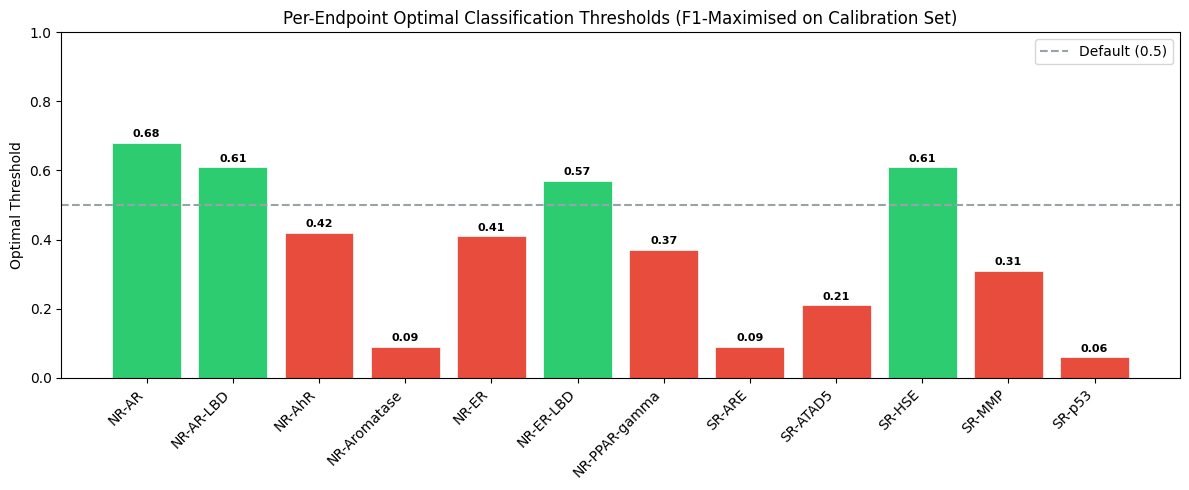

Threshold calibration plot saved.


In [9]:
# ── Step 5: Threshold Calibration Plot ────────────────────────────────────────
# Show how far the optimal thresholds deviate from the naive 0.5 default.

eps    = list(optimal_thresholds.keys())
thrs   = list(optimal_thresholds.values())
colors = ['#e74c3c' if t < 0.5 else '#2ecc71' for t in thrs]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(eps, thrs, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0.5, color='#95a5a6', linestyle='--', linewidth=1.5, label='Default (0.5)')
ax.set_ylabel('Optimal Threshold')
ax.set_title('Per-Endpoint Optimal Classification Thresholds (F1-Maximised on Calibration Set)')
ax.set_ylim(0, 1)
ax.legend()

for bar, thr in zip(bars, thrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{thr:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/threshold_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Threshold calibration plot saved.')

In [1]:
# Re-run SHAP summary with fixed indexing (no recomputation needed)
from src.explain import build_global_shap_summary, get_top_shap_bits

shap_summary = build_global_shap_summary(artifact['shap_values'], TARGET_COLS, top_k=15)

print('Top-5 most important FINGERPRINT bits per endpoint:')
for ep, bits in shap_summary.items():
    top5 = [f"bit_{b['bit']}({b['importance']:.4f})" for b in bits[:5]]
    print(f'  {ep}: {top5}')


ModuleNotFoundError: No module named 'src'